# Deep-Dive Analysis & Interactive Dashboarding

This notebook is designed as a stronger Task 3 submission and includes:
- KPI definitions with formulas and business rationale
- Cohort retention analysis
- Funnel conversion and drop-off analysis
- Customer segmentation using RFM-style scoring
- Interactive Plotly dashboard views

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.random.seed(42)
pd.options.display.float_format = '{:,.2f}'.format

print('Libraries loaded')

Libraries loaded


## 1. KPI Definitions

Below are five core business KPIs used in this notebook.

1. **Revenue**  
   Formula: `sum(order_value)`  
   Why it matters: Measures total sales generated over the analysis period.

2. **Average Order Value (AOV)**  
   Formula: `total revenue / total orders`  
   Why it matters: Shows how much customers spend per order on average.

3. **Purchase Conversion Rate**  
   Formula: `purchases / visits`  
   Why it matters: Measures how efficiently traffic turns into paying customers.

4. **Customer Retention Rate**  
   Formula: `customers retained in later periods / customers in original cohort`  
   Why it matters: Helps evaluate loyalty and repeat purchase behavior.

5. **Customer Churn Rate**  
   Formula: `1 - retention rate`  
   Why it matters: Indicates how many customers stop engaging or buying over time.

## 2. Create Example Business Data

Synthetic data is generated here so the notebook runs end-to-end. Replace these tables with your real dataset if available.

In [3]:
# Create customer master data
n_customers = 180
customer_ids = np.arange(1, n_customers + 1)
signup_dates = pd.to_datetime(
    np.random.choice(pd.date_range('2023-01-01', '2023-09-30', freq='D'), n_customers)
)

customers = pd.DataFrame({
    'customer_id': customer_ids,
    'signup_date': signup_dates
}).sort_values('signup_date').reset_index(drop=True)

# Create order-level transactional data
orders = []
order_id = 1000

for _, row in customers.iterrows():
    customer_id = row['customer_id']
    signup_date = row['signup_date']
    n_orders = np.random.poisson(3) + 1

    for _ in range(n_orders):
        order_gap = np.random.randint(0, 180)
        order_date = signup_date + pd.Timedelta(days=int(order_gap))
        if order_date > pd.Timestamp('2024-03-31'):
            order_date = pd.Timestamp('2024-03-31')

        order_value = np.random.gamma(shape=4, scale=40)
        category = np.random.choice(['Electronics', 'Fashion', 'Home', 'Beauty'], p=[0.30, 0.25, 0.25, 0.20])

        orders.append({
            'order_id': order_id,
            'customer_id': customer_id,
            'order_date': order_date,
            'order_value': round(order_value, 2),
            'category': category
        })
        order_id += 1

orders_df = pd.DataFrame(orders).sort_values('order_date').reset_index(drop=True)

# Create simple funnel/session data
visits = 3500
visited = visits
added_to_cart = int(visited * 0.58)
purchased = len(orders_df)

funnel_df = pd.DataFrame({
    'stage': ['Visited', 'Added to Cart', 'Purchased'],
    'count': [visited, added_to_cart, purchased]
})

orders_df.head()

,order_id,customer_id,order_date,order_value,category
0,1029,6,2023-01-21,223.47,Electronics
1,1036,18,2023-01-23,152.08,Home
2,1012,116,2023-02-08,147.66,Fashion
3,1045,126,2023-02-09,131.72,Electronics
4,1073,80,2023-02-13,55.12,Home


## 3. KPI Calculation

In [4]:
total_revenue = orders_df['order_value'].sum()
total_orders = orders_df['order_id'].nunique()
unique_customers = orders_df['customer_id'].nunique()
aov = total_revenue / total_orders
conversion_rate = purchased / visited

# Simple repeat-customer retention proxy
orders_per_customer = orders_df.groupby('customer_id')['order_id'].nunique()
retained_customers = (orders_per_customer > 1).sum()
retention_rate = retained_customers / unique_customers
churn_rate = 1 - retention_rate

kpi_summary = pd.DataFrame({
    'KPI': ['Revenue', 'Orders', 'Customers', 'AOV', 'Conversion Rate', 'Retention Rate', 'Churn Rate'],
    'Value': [
        round(total_revenue, 2),
        total_orders,
        unique_customers,
        round(aov, 2),
        round(conversion_rate, 4),
        round(retention_rate, 4),
        round(churn_rate, 4)
    ]
})

kpi_summary

,KPI,Value
0,Revenue,"113,675.10"
1,Orders,720.00
2,Customers,180.00
3,AOV,157.88
4,Conversion Rate,0.21
5,Retention Rate,0.97
6,Churn Rate,0.03


## 4. Monthly Revenue Trend

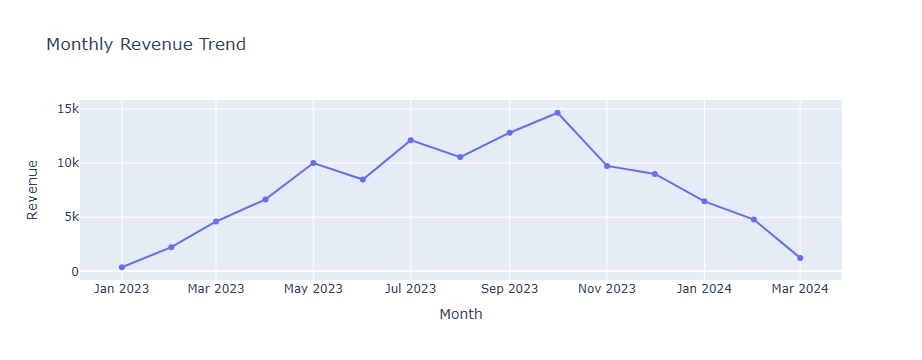

In [5]:
orders_df['order_month'] = orders_df['order_date'].dt.to_period('M').dt.to_timestamp()
monthly_revenue = orders_df.groupby('order_month', as_index=False).agg(
    revenue=('order_value', 'sum'),
    orders=('order_id', 'count'),
    customers=('customer_id', 'nunique')
)

fig = px.line(
    monthly_revenue,
    x='order_month',
    y='revenue',
    markers=True,
    title='Monthly Revenue Trend'
)
fig.update_layout(xaxis_title='Month', yaxis_title='Revenue')
fig.show()

## 5. Cohort Analysis

This section calculates customer retention by cohort month based on each customer's first purchase.

In [6]:
cohort_base = orders_df.copy()
cohort_base['order_month_period'] = cohort_base['order_date'].dt.to_period('M')
cohort_base['cohort_month'] = cohort_base.groupby('customer_id')['order_date'].transform('min').dt.to_period('M')

cohort_base['cohort_index'] = (
    (cohort_base['order_month_period'].dt.year - cohort_base['cohort_month'].dt.year) * 12 +
    (cohort_base['order_month_period'].dt.month - cohort_base['cohort_month'].dt.month)
)

cohort_data = cohort_base.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_id')
cohort_size = cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0).round(3)

retention_display = (retention_matrix * 100).fillna(0)
retention_display

cohort_index,0,1,2,3,4,5,6
cohort_month,,,,,,,
2023-01,100.00,0.00,50.00,50.00,50.00,0.00,50.00
2023-02,100.00,40.00,30.00,60.00,50.00,40.00,0.00
2023-03,100.00,66.70,50.00,27.80,50.00,38.90,0.00
2023-04,100.00,31.20,43.80,50.00,56.20,31.20,0.00
2023-05,100.00,36.00,44.00,32.00,44.00,24.00,4.00
2023-06,100.00,26.70,33.30,46.70,40.00,26.70,6.70
2023-07,100.00,38.10,42.90,52.40,33.30,38.10,4.80
2023-08,100.00,63.20,73.70,36.80,47.40,26.30,0.00
2023-09,100.00,47.60,23.80,47.60,47.60,28.60,4.80


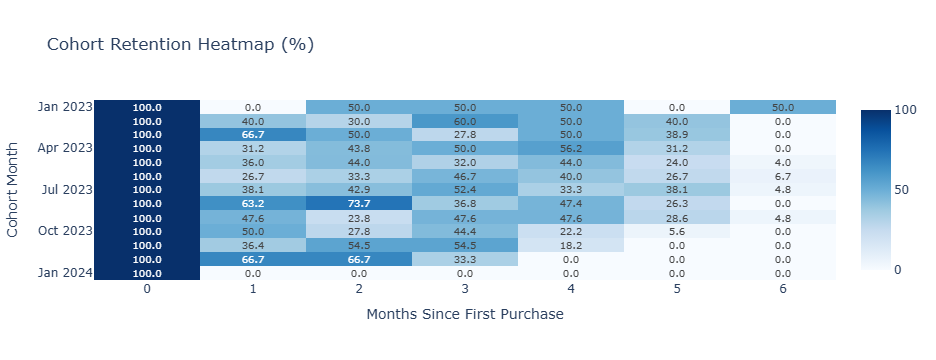

In [7]:
# Convert the Period index and integer columns to strings
retention_display.index = retention_display.index.astype(str)
retention_display.columns = retention_display.columns.astype(str)

# Now plot
fig = px.imshow(
    retention_display, 
    text_auto='.1f', 
    aspect='auto', 
    color_continuous_scale='Blues', 
    title='Cohort Retention Heatmap (%)'
)
fig.update_layout(xaxis_title='Months Since First Purchase', yaxis_title='Cohort Month')
fig.show()

## 6. Funnel Analysis

This funnel highlights both scale and conversion efficiency across the customer journey.

In [8]:
funnel_df['conversion_from_previous'] = funnel_df['count'] / funnel_df['count'].shift(1)
funnel_df.loc[0, 'conversion_from_previous'] = 1.0
funnel_df['drop_off_from_previous'] = 1 - funnel_df['conversion_from_previous']
funnel_df['overall_conversion'] = funnel_df['count'] / funnel_df.loc[0, 'count']

funnel_df

,stage,count,conversion_from_previous,drop_off_from_previous,overall_conversion
0,Visited,3500,1.00,0.00,1.00
1,Added to Cart,2029,0.58,0.42,0.58
2,Purchased,720,0.35,0.65,0.21


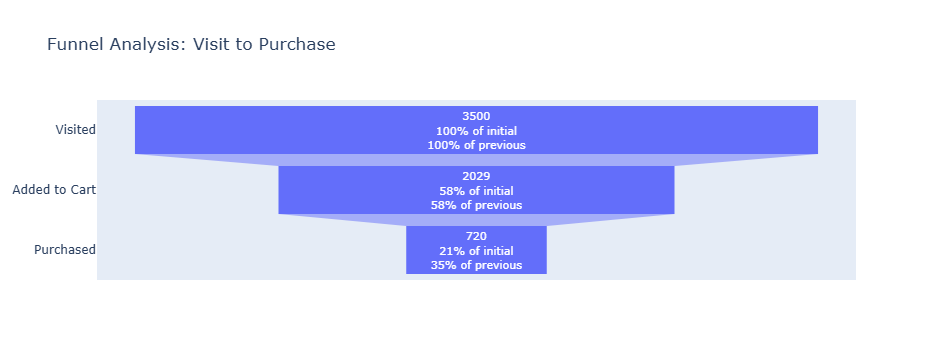

In [9]:
fig = go.Figure(go.Funnel(
    y=funnel_df['stage'],
    x=funnel_df['count'],
    textinfo='value+percent initial+percent previous'
))
fig.update_layout(title='Funnel Analysis: Visit to Purchase')
fig.show()

## 7. Customer Segmentation

This segmentation uses a simple RFM-style model:
- **Recency**: how recently a customer placed an order
- **Frequency**: how often they order
- **Monetary**: how much revenue they generated

In [10]:
snapshot_date = orders_df['order_date'].max() + pd.Timedelta(days=1)

rfm = orders_df.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'count'),
    Monetary=('order_value', 'sum')
).reset_index()

rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

rfm['segment'] = pd.cut(
    rfm['RFM_score'],
    bins=[0, 5, 8, 10, 12],
    labels=['At Risk', 'Promising', 'Loyal', 'Champions']
)

segment_summary = rfm.groupby('segment', observed=False).agg(
    customers=('customer_id', 'count'),
    avg_recency=('Recency', 'mean'),
    avg_frequency=('Frequency', 'mean'),
    avg_monetary=('Monetary', 'mean')
).reset_index()

segment_summary

,segment,customers,avg_recency,avg_frequency,avg_monetary
0,At Risk,43,218.86,2.28,330.62
1,Promising,77,163.62,3.66,579.51
2,Loyal,35,144.69,5.40,838.18
3,Champions,25,69.64,6.04,"1,020.01"


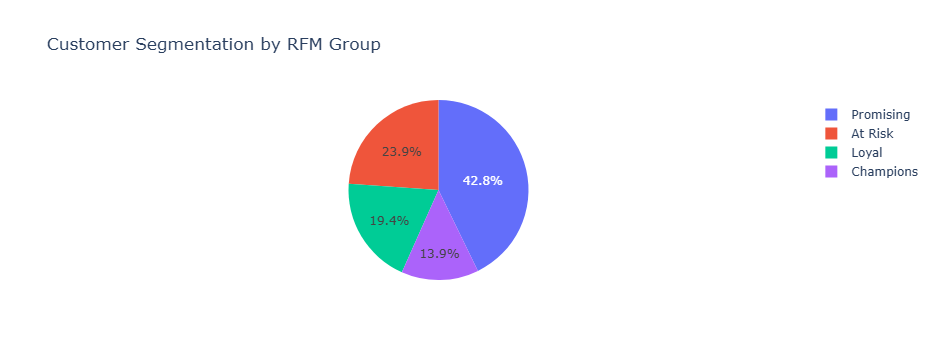

In [11]:
fig = px.pie(
    segment_summary,
    values='customers',
    names='segment',
    title='Customer Segmentation by RFM Group'
)
fig.show()

## 8. Interactive Dashboard

This Plotly dashboard combines KPI cards and major analysis views in a single interactive figure.

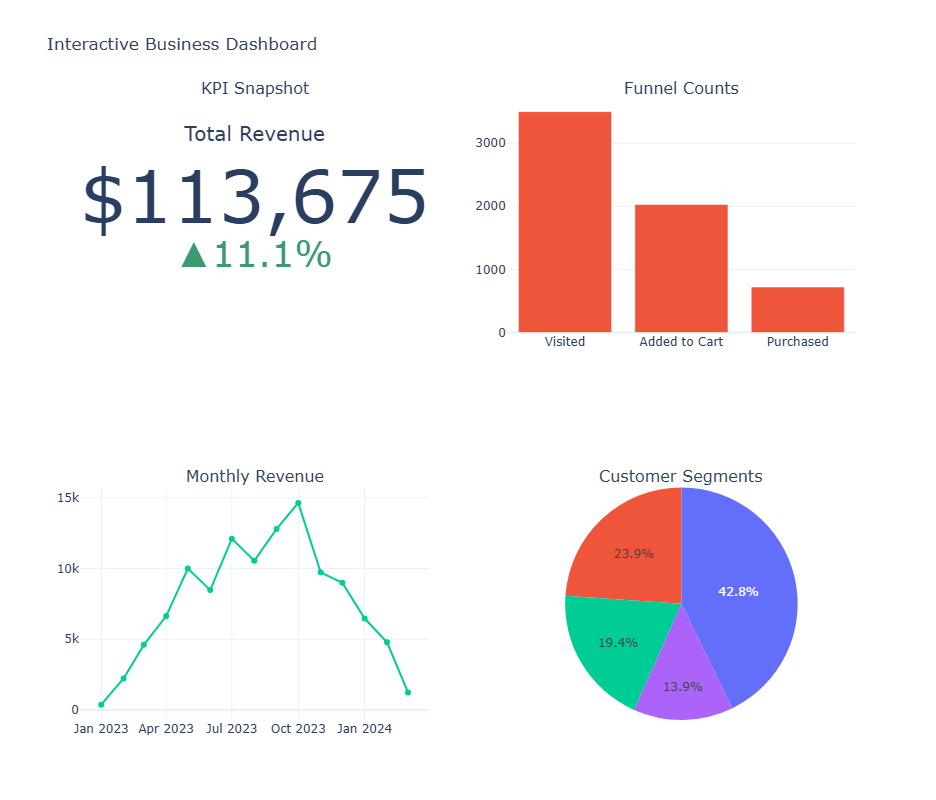

In [12]:
dashboard = make_subplots(
    rows=2,
    cols=2,
    specs=[[{'type': 'indicator'}, {'type': 'bar'}], [{'type': 'scatter'}, {'type': 'domain'}]],
    subplot_titles=('KPI Snapshot', 'Funnel Counts', 'Monthly Revenue', 'Customer Segments')
)

dashboard.add_trace(
    go.Indicator(
        mode='number+delta',
        value=total_revenue,
        number={'prefix': '$', 'valueformat': ',.0f'},
        delta={'reference': total_revenue * 0.9, 'relative': True, 'valueformat': '.1%'},
        title={'text': 'Total Revenue'}
    ),
    row=1,
    col=1
)

dashboard.add_trace(
    go.Bar(x=funnel_df['stage'], y=funnel_df['count'], name='Funnel'),
    row=1,
    col=2
)

dashboard.add_trace(
    go.Scatter(
        x=monthly_revenue['order_month'],
        y=monthly_revenue['revenue'],
        mode='lines+markers',
        name='Revenue'
    ),
    row=2,
    col=1
)

dashboard.add_trace(
    go.Pie(labels=segment_summary['segment'], values=segment_summary['customers'], name='Segments'),
    row=2,
    col=2
)

dashboard.update_layout(
    title='Interactive Business Dashboard',
    height=800,
    showlegend=False,
    template='plotly_white'
)

dashboard.show()

## 9. Key Business Insights

- Revenue and AOV help assess sales performance and customer spend quality.
- Cohort retention shows whether newly acquired customers continue buying over time.
- Funnel drop-off highlights where the business loses the most potential conversions.
- RFM segmentation helps prioritize retention campaigns, loyalty offers, and reactivation efforts.
- The interactive dashboard brings these views together for faster decision-making.